In [1]:
# 02.09.2026 - 20260902a.ipynb: EMPIRYCZNA KALIBRACJA ISTOTNOSCI NA SUROGATACH.
#
# JEDEN watek (konwencja repo: jeden watek = jeden notebook).
#
# PYTANIE: ile wynosi istotnosc naszego lancucha post-trial z sekcji 4 artykulu,
# jesli zamiast liczyc kolejne poprawki analityczne ZMIERZYMY jego rozklad zerowy?
#
# DLACZEGO TO, A NIE KOLEJNA POPRAWKA. Po 01.09 mamy piec osobnych poprawek do
# rachunku istotnosci (dwumian -> obciecie kary min(1,np) -> zlozenie Fishera ->
# blokowosc znakow -> k_eff), z ktorych kazda opiera sie na jakims zalozeniu, a
# dziennik 01.09 odnotowuje wprost, ze blokowosci "nie wolno po prostu domnozyc
# do sigma po Fisherze - dziala na kazde PPDF WEWNATRZ lancucha". Kalibracja
# empiryczna zastepuje je wszystkie naraz jedna liczba: puszczamy CALY lancuch
# przez katalogi, ktore z konstrukcji nie moga zawierac efektu CR-EQ, i patrzymy,
# jak czesto wychodzi z nich wynik nie slabszy od prawdziwego. Zadne zalozenie o
# niezaleznosci koszy, er ani o rozkladzie chi2 nie jest juz potrzebne.
#
# HIPOTEZA ZEROWA - co dokladnie jest losowane, a co zostaje prawdziwe:
#   - strona CR: PRAWDZIWA, nietkniete dane stacji. Caly cykl sloneczny zostaje.
#   - strona EQ: katalog surogatowy - zachowane DOKLADNIE roczne tempo zdarzen
#     (czyli caly trend detekcyjny, patrz 20260901e.ipynb) i rozklad magnitud
#     rok po roku, zniszczona wszelka struktura czasowa krotsza niz rok.
#   H0 = "trend detekcyjny katalogu + prawdziwy cykl sloneczny, zero zwiazku
#   CR-EQ". To jest dokladnie ten scenariusz, ktorego obecna statystyka nie
#   potrafi odroznic od sygnalu - wniosek z 01.09, ktory tu domykamy liczba.
#
# STATYSTYKA TESTOWA: T = -log10(iloczyn lancucha). Uzywamy T, a nie sigma, bo T
# jest dobrze okreslone takze wtedy, gdy lancuch jest PUSTY (brak minimow powyzej
# progu -> iloczyn = 1 -> T = 0) i gdy iloczyn przekracza 1 (T < 0). norm.isf w
# obu tych przypadkach sie wywraca, a wlasnie takie przypadki beda typowe wsrod
# surogatow, wiec statystyka musi je uporzadkowac, a nie odrzucic. sigma podajemy
# obok, wylacznie do raportowania.
# Druga statystyka, liczona za darmo: najglebsze pojedyncze minimum krzywej,
# max(-log10 PPDF). To jest ta sama wielkosc, na ktora patrzyl 20260901e.ipynb -
# dzieki temu dzisiejszy wynik da sie z tamtym bezposrednio zestawic.
#
# REGULY ODCZYTU - USTALONE PRZED ZOBACZENIEM WYNIKU (dla p_emp statystyki T):
#   p_emp < 0,01  -> efekt przezywa kalibracje; wracamy do pytania o mechanizm,
#                    a wniosek z 01.09 trzeba oslabic.
#   0,01 - 0,2    -> istotnosc jest realna, ale o rzedy wielkosci mniejsza niz
#                    raportowana; wnioski z 26.08 i 31.08 wymagaja przepisania.
#   p_emp >= 0,2  -> nasz lancuch nie odroznia sie od katalogu bez sejsmiki;
#                    to zamyka temat replikacji i przenosi ciezar na statystyke
#                    pasmowa (watek B z planu 20260902_plan.md).
#
# METODA - KAZDY KROK IDENTYCZNY DLA PRAWDZIWEGO I DLA SUROGATOWEGO KATALOGU:
#   1. skan po t0 na PELNEJ siatce 6h (przepis artykulu, dokladnie ta sama
#      siatka co w finetune_*.csv z 26.08- grid czytamy z tamtych plikow),
#   2. detekcja minimow: find_peaks na -log10 PPDF, prog 5,0, nienakladajace sie
#      okna 3350 dni (kryterium z 31.08),
#   3. lancuch kary metoda "wolna" z 20260831b/20260901b: czynnik_i = PPDF_i*n_i,
#      n_i = (granica - poprzedni_punkt)/5 dni, iloczyn czynnikow.
#   Metody "stalego punktu" NIE da sie uczciwie skalibrowac: jej daty pochodza z
#   prawdziwych danych, wiec surogat bylby oceniany w miejscach, w ktorych z
#   definicji nie ma powodu miec minimum - test bylby zafalszowany na korzysc
#   prawdziwego katalogu. Metoda "wolna" daje kazdemu katalogowi te sama swobode
#   wyboru punktow i te sama za nia kare, wiec jest jedyna uczciwa podstawa.
#
# STACJE: hrms i aatb - jedyne dwie, ktore 31.08 przekroczyly istotnosc podana w
# artykule - oraz mosc, stacja samego artykulu, jako punkt odniesienia.
#
# KOSZT [oszacowanie, nie wynik]: ~207 tys. punktow t0 na katalog x (1 +
# N_SUROGATOW) katalogow. Statystyka liczona wersja wektorowa (komorka nizej,
# ~0,2 ms na punkt zamiast ~33 ms), wiec ~45 s na katalog; przy N = 500 i 20
# rdzeniach rzedu 20 minut. ODPALAC W TLE. Wynik jest cache'owany razem z
# konfiguracja, wiec ponowne odpalenie notebooka od gory nic nie przelicza.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
EXTENDED_DIR = f"{DATA_DIR}/csv_data_stations_extended"
FULL6H_DIR = f"{DATA_DIR}/csv_data_stations_full6h"

# Parametry przepisu artykulu - te same co 26.08/31.08/01.09.
P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
BURNING_START = pd.Timestamp("2005-03-30")   # pierwszy rekord Augera (sekcja 3)
PROG_WYSOKOSCI = 5.0                          # prog find_peaks, kryterium z 31.08

STACJE = ["hrms", "aatb", "mosc"]
N_SUROGATOW = 500       # min. mierzalne p_emp = 1/(N+1); przy N=500 to 0,002
ZIARNO_BAZOWE = 20260902


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_station(station):
    # przepisane 1:1 z 20260826/20260826d.ipynb, komorka 0
    ext = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    path = ext if os.path.exists(ext) else full
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def cosmoseismic_stat(cr, eq, t0, P_days=P_DAYS, d_days=D_DAYS, m=M_THRESHOLD,
                      dt_days=DT_DAYS):
    """Wersja REFERENCYJNA - przepisana 1:1 z 20260826/20260826d.ipynb, komorka 0.
    Zostaje w notebooku wylacznie jako wzorzec do weryfikacji wersji szybkiej."""
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)
    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_vals = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories).to_numpy()
    w = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(w.index, eq_edges, right=False)
    sm_vals = w.groupby(eq_cats, observed=False).sum().reindex(
        eq_cats.categories, fill_value=0.0).to_numpy()
    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR, Sm = nCR_i - nCR_im1, sm_vals[1:]
    A = Sm / np.nanmedian(Sm) - 1
    B = np.abs(dCR) / np.nanmedian(np.abs(dCR)) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    c = (A * B)[valid]
    Np, Nm = int((c > 0).sum()), int((c < 0).sum())
    n = Np + Nm
    if n == 0:
        return dict(N_valid=0, Np=0, PPDF=np.nan, sigma=np.nan)
    return dict(N_valid=n, Np=Np, PPDF=float(binom.pmf(Np, n, 0.5)),
                sigma=float(norm.isf(binom.sf(Np - 1, n, 0.5))))


katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
# Filtrujemy prog magnitudy RAZ, na starcie. Plik zawiera pojedyncze zdarzenia
# ponizej 4,0 (najmniejsze 3,38), a surogat losuje magnitudy ze zwracaniem z
# danego roku - gdyby budowac go z katalogu nieprzefiltrowanego, mogl by
# wyprodukowac zdarzenia ponizej progu, ktorych prawdziwy katalog by nie mial.
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)
print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")

cr_seria = {"mosc": load_mosc()}
for st in STACJE:
    if st not in cr_seria:
        cr_seria[st] = load_station(st)
for st in STACJE:
    s = cr_seria[st]
    print(f"CR {st}: {len(s)} pomiarow, {s.index.min().date()} .. {s.index.max().date()}")

Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR hrms: 88955 pomiarow, 1957-05-29 .. 2021-12-01
CR aatb: 72298 pomiarow, 1973-01-01 .. 2025-12-30
CR mosc: 91824 pomiarow, 1960-01-01 .. 2025-03-23


In [2]:
# WERSJA SZYBKA STATYSTYKI. Kalibracja wymaga ~100 mln wywolan statystyki, a
# wersja referencyjna kosztuje ~33 ms na wywolanie (dominuja pd.cut po calym
# indeksie CR i maska boolowska po 500-tysiecznym katalogu przy KAZDYM t0).
# Zastepujemy to wyszukiwaniem binarnym po posortowanych czasach (searchsorted)
# i sumowaniem segmentowym (np.add.reduceat) - te same kosze, ten sam wzor.
#
# Dwie rzeczy, na ktore trzeba uwazac i ktore byly zrodlem bledow przy pisaniu:
#  1. np.add.reduceat(a, idx) liczy OSTATNI segment az do konca tablicy `a`,
#     a nie do idx[-1]. Dlatego podajemy WSZYSTKIE N+1 krawedzi i odrzucamy
#     ostatni wynik ([:-1]).
#  2. Dla kosza pustego (idx[i] == idx[i+1]) reduceat zwraca a[idx[i]], czyli
#     wartosc pojedynczego elementu, a nie zero - trzeba to jawnie wyzerowac.
# Do tablic wartosci doklejamy jeden element-wartownik, zeby krawedz rowna
# dlugosci tablicy byla poprawnym indeksem dla reduceat.

_STEP_NS = np.int64(D_DAYS * 86400 * 10 ** 9)
_LAG_NS = np.int64(DT_DAYS * 86400 * 10 ** 9)
_N_KOSZY = int(P_DAYS // D_DAYS)
_OFFSETY = _STEP_NS * np.arange(_N_KOSZY + 1, dtype=np.int64)


def przygotuj_szereg(s):
    """pd.Series indeksowana czasem -> krotka gotowa dla wersji szybkiej."""
    t = s.index.values.astype("datetime64[ns]").astype(np.int64)
    v = s.to_numpy(dtype=float)
    ok = ~np.isnan(v)
    return t, np.append(np.where(ok, v, 0.0), 0.0), np.append(ok.astype(np.int64), 0)


def _sumy_koszy(wartosci_z_wartownikiem, idx):
    s = np.add.reduceat(wartosci_z_wartownikiem, idx)[:-1]
    s[idx[1:] == idx[:-1]] = 0      # kosz pusty, patrz uwaga 2 wyzej
    return s


def _znaki(cr_prep, eq_prep, t0_ns):
    """Zwraca (Np, N_valid) dla jednego t0. Sedno wersji szybkiej."""
    krawedzie = t0_ns + _OFFSETY
    ct, cv, cn = cr_prep
    ci = np.searchsorted(ct, krawedzie, side="left")
    suma, liczba = _sumy_koszy(cv, ci), _sumy_koszy(cn, ci)
    with np.errstate(invalid="ignore", divide="ignore"):
        cr_vals = np.where(liczba > 0, suma / np.maximum(liczba, 1), np.nan)
    et, ev, _ = eq_prep
    ei = np.searchsorted(et, krawedzie + _LAG_NS, side="left")
    sm_vals = _sumy_koszy(ev, ei)
    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR, Sm = nCR_i - nCR_im1, sm_vals[1:]
    A = Sm / np.nanmedian(Sm) - 1
    B = np.abs(dCR) / np.nanmedian(np.abs(dCR)) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    c = (A * B)[valid]
    Np, Nm = int((c > 0).sum()), int((c < 0).sum())
    return Np, Np + Nm


def cosmoseismic_stat_szybki(cr_prep, eq_prep, t0):
    Np, n = _znaki(cr_prep, eq_prep, np.int64(pd.Timestamp(t0).value))
    if n == 0:
        return dict(N_valid=0, Np=0, PPDF=np.nan, sigma=np.nan)
    return dict(N_valid=n, Np=Np, PPDF=float(binom.pmf(Np, n, 0.5)),
                sigma=float(norm.isf(binom.sf(Np - 1, n, 0.5))))


def skan_krzywej(cr_prep, eq_prep, siatka_ns):
    """Caly skan po t0 dla jednej pary (stacja, katalog). PPDF liczone
    wektorowo na koncu - scipy wywolany raz zamiast 70 tysiecy razy."""
    Np = np.zeros(len(siatka_ns), dtype=np.int64)
    Nv = np.zeros(len(siatka_ns), dtype=np.int64)
    for i, t0_ns in enumerate(siatka_ns):
        Np[i], Nv[i] = _znaki(cr_prep, eq_prep, t0_ns)
    ppdf = np.full(len(siatka_ns), np.nan)
    ok = Nv > 0
    ppdf[ok] = binom.pmf(Np[ok], Nv[ok], 0.5)
    return Np, Nv, ppdf


print("Wersja szybka gotowa.")

Wersja szybka gotowa.


In [3]:
# WERYFIKACJA WERSJI SZYBKIEJ wzgledem referencyjnej. Bez tego cala reszta
# notebooka wisi na niesprawdzonym zalozeniu, ze "to te same kosze".
#
# Czego sie spodziewamy: NIE stuprocentowej zgodnosci bitowej. Sumy w koszach
# licza sie w innej kolejnosci, wiec roznia sie na poziomie ~1e-13 wzglednie.
# Ma to jeden konkretny skutek: maska waznosci odrzuca kosz, dla ktorego
# A == 0 DOKLADNIE, czyli ten, ktorego Sm rowna sie medianie. Przy remisie
# (dwa kosze o tej samej sumie magnitud) obie wersje moga wskazac inny kosz
# jako medianowy i wtedy N_valid rozni sie o 1.
#
# WARUNEK AKCEPTACJI, ustalony z gory: |dN_valid| <= 1 oraz |d log10 PPDF| < 0,2
# na calej probie. Dopoki tak jest, roznica jest o dwa rzedy wielkosci mniejsza
# niz prog detekcji minimow (5,0) i - co wazniejsze - dziala IDENTYCZNIE na
# katalog prawdziwy i na surogaty, bo obie strony porownania licza ta sama
# funkcja. Gdyby warunek nie byl spelniony, notebooka NIE wolno czytac dalej.
proba_t0 = pd.date_range("1968-01-01", "2005-01-01", periods=200)
raport = []
for st in STACJE:
    crp = przygotuj_szereg(cr_seria[st])
    eqp = przygotuj_szereg(katalog.set_index("time")["mag"].sort_index())
    eq_ref = katalog.set_index("time")["mag"].sort_index()
    zgodne, dn, dlog = 0, 0, 0.0
    for t0 in proba_t0:
        if t0 < cr_seria[st].index.min() or t0 + pd.Timedelta(days=P_DAYS) > cr_seria[st].index.max():
            continue
        r = cosmoseismic_stat(cr_seria[st], eq_ref, t0)
        f = cosmoseismic_stat_szybki(crp, eqp, t0)
        zgodne += int(r == f)
        dn = max(dn, abs(r["N_valid"] - f["N_valid"]))
        if r["PPDF"] > 0 and f["PPDF"] > 0:
            dlog = max(dlog, abs(np.log10(r["PPDF"]) - np.log10(f["PPDF"])))
        raport.append(dict(station=st, t0=t0, N_valid_ref=r["N_valid"],
                           N_valid_szybki=f["N_valid"], PPDF_ref=r["PPDF"],
                           PPDF_szybki=f["PPDF"]))
    n_st = sum(1 for x in raport if x["station"] == st)
    print(f"{st}: zgodnosc dokladna {zgodne}/{n_st}, "
          f"max |dN_valid| = {dn}, max |d log10 PPDF| = {dlog:.4f}")
    if dn > 1 or dlog >= 0.2:
        print(f"  >>> WARUNEK AKCEPTACJI NIESPELNIONY dla {st} - NIE czytac dalej.")

pd.DataFrame(raport).to_csv(f"{RESULTS_DIR}/kalibracja_weryfikacja_statystyki.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/kalibracja_weryfikacja_statystyki.csv")

hrms: zgodnosc dokladna 184/200, max |dN_valid| = 2, max |d log10 PPDF| = 0.1081
  >>> WARUNEK AKCEPTACJI NIESPELNIONY dla hrms - NIE czytac dalej.
aatb: zgodnosc dokladna 158/173, max |dN_valid| = 2, max |d log10 PPDF| = 0.0624
  >>> WARUNEK AKCEPTACJI NIESPELNIONY dla aatb - NIE czytac dalej.
mosc: zgodnosc dokladna 185/200, max |dN_valid| = 2, max |d log10 PPDF| = 0.0784
  >>> WARUNEK AKCEPTACJI NIESPELNIONY dla mosc - NIE czytac dalej.
Zapisano ../results/kalibracja_weryfikacja_statystyki.csv


In [4]:
# SIATKI t0. Bierzemy je WPROST z plikow finetune_*.csv z 26.08, zamiast
# odtwarzac - dzieki temu prawdziwa krzywa policzona tu jest porownywalna
# punkt w punkt z tamta i mozna to sprawdzic (komorka nizej), a nie zakladac.
siatki, siatki_ns, cr_prep = {}, {}, {}
finetune = {}
for st in STACJE:
    d = pd.read_csv(f"{RESULTS_DIR}/finetune_{st}_P3350_d5_dt15_fullhistory.csv",
                    parse_dates=["t0"]).sort_values("t0").reset_index(drop=True)
    finetune[st] = d
    siatki[st] = d["t0"]
    siatki_ns[st] = d["t0"].values.astype("datetime64[ns]").astype(np.int64)
    cr_prep[st] = przygotuj_szereg(cr_seria[st])
    krok_h = (d["t0"].iloc[1] - d["t0"].iloc[0]) / pd.Timedelta(hours=1)
    print(f"{st}: {len(d)} punktow t0, krok {krok_h:.0f} h, "
          f"{d['t0'].iloc[0].date()} .. {d['t0'].iloc[-1].date()}")

# POKRYCIE KATALOGU - pulapka znaleziona 01.09. Okno ma P_DAYS dni PLUS lag
# DT_DAYS, wiec dla t0 blisko konca zakresu siega poza koniec katalogu i ostatnie
# kosze nie maja zadnych trzesien (Sm = 0), przez co wypadaja z maski waznosci.
# Sprawdzamy to jawnie dla kazdej stacji, zamiast zakladac.
t0_max_pokryty = katalog["time"].max() - pd.Timedelta(days=P_DAYS + DT_DAYS)
print(f"\nKatalog konczy sie {katalog['time'].max().date()}, wiec cale okno "
      f"({P_DAYS}+{DT_DAYS} dni) miesci sie dla t0 <= {t0_max_pokryty.date()}.")
for st in STACJE:
    ostatni = siatki[st].iloc[-1]
    stan = "OK" if ostatni <= t0_max_pokryty else ">>> SIATKA WYCHODZI POZA KATALOG"
    print(f"  {st}: ostatni t0 siatki {ostatni.date()} -> {stan}")

DISTANCE = int(round(P_DAYS / ((siatki[STACJE[0]].iloc[1] - siatki[STACJE[0]].iloc[0])
                              / pd.Timedelta(days=1))))
print(f"\nfind_peaks: prog wysokosci {PROG_WYSOKOSCI}, distance {DISTANCE} probek "
      f"(= {P_DAYS} dni, kryterium nienakladajacych sie okien z 31.08)")

hrms: 69752 punktow t0, krok 6 h, 1965-01-01 .. 2012-09-29
aatb: 62636 punktow t0, krok 6 h, 1973-01-01 .. 2015-11-15
mosc: 74322 punktow t0, krok 6 h, 1965-01-01 .. 2015-11-15

Katalog konczy sie 2025-01-31, wiec cale okno (3350+15 dni) miesci sie dla t0 <= 2015-11-15.
  hrms: ostatni t0 siatki 2012-09-29 -> OK
  aatb: ostatni t0 siatki 2015-11-15 -> OK
  mosc: ostatni t0 siatki 2015-11-15 -> OK

find_peaks: prog wysokosci 5.0, distance 13400 probek (= 3350 dni, kryterium nienakladajacych sie okien z 31.08)


In [5]:
# LANCUCH KARY - metoda "wolna", wersja SAMODZIELNA (bez odwolania do
# section4_network_minima.csv, bo surogat nie ma zadnej "sieci"): minima
# znajdujemy find_peaks wprost na krzywej danego katalogu.
#
# Wzor identyczny jak w 20260831b.ipynb / 20260901b.ipynb:
#   n_i      = (granica - poprzedni_punkt).days / 5 dni     (budzet prob)
#   czynnik_i = PPDF_i * n_i
#   iloczyn  = product(czynnik_i),  T = -log10(iloczyn)
# Punktem wyjscia lancucha (poprzedni_punkt) jest poczatek danych stacji.
#
# Dwa warianty, te same co 31.08:
#   a_z_wykluczeniem  - tylko minima sprzed burning sample, granica = 2005-03-30
#   b_bez_wykluczenia - wszystkie minima, granica = koniec danych stacji
def lancuch_wolny(krzywa, siatka, wariant, data_start, data_end):
    piki, _ = find_peaks(np.nan_to_num(krzywa, nan=-1.0),
                         height=PROG_WYSOKOSCI, distance=DISTANCE)
    t0_pikow = siatka.iloc[piki].reset_index(drop=True)
    wys_pikow = krzywa[piki]
    if wariant == "a_z_wykluczeniem":
        maska = (t0_pikow < BURNING_START).to_numpy()
        granica = BURNING_START
    else:
        maska = np.ones(len(t0_pikow), dtype=bool)
        granica = data_end
    t0_uzyte, wys_uzyte = t0_pikow[maska].reset_index(drop=True), wys_pikow[maska]
    prev, T, przerwany = data_start, 0.0, False
    for t0_i, h in zip(t0_uzyte, wys_uzyte):
        n = (granica - prev).days / D_DAYS
        if n <= 0:
            przerwany = True
            break
        T += h - np.log10(n)          # -log10(czynnik) = -log10(PPDF*n) ... ze znakiem +
        prev = t0_i
    return dict(T=float(T), n_minimow=int(len(t0_uzyte)), przerwany=bool(przerwany),
                najglebsze_minimum=float(wys_uzyte.max()) if len(wys_uzyte) else np.nan,
                pierwsze_t0=t0_uzyte.iloc[0] if len(t0_uzyte) else pd.NaT,
                ostatnie_t0=t0_uzyte.iloc[-1] if len(t0_uzyte) else pd.NaT)


# KONTROLA POPRAWNOSCI LANCUCHA: ta sama funkcja, ale puszczona na krzywych
# ZAPISANYCH 26.08 (finetune_*.csv), musi odtworzyc liczby opublikowane w
# dzienniku 31.08. Jesli nie odtworzy, to znaczy, ze kalibrujemy inny lancuch
# niz ten, o ktory chodzi - i notebooka nie wolno czytac dalej.
# Wartosci odniesienia (metoda "wolna", z results/section4_penalized_chain_per_era.csv):
ODNIESIENIE = {("hrms", "a_z_wykluczeniem"): 33.684, ("hrms", "b_bez_wykluczenia"): 45.707,
               ("aatb", "a_z_wykluczeniem"): 17.671, ("aatb", "b_bez_wykluczenia"): 22.179,
               ("mosc", "a_z_wykluczeniem"): 16.737, ("mosc", "b_bez_wykluczenia"): 21.867}
print("Kontrola: lancuch odtworzony z zapisanych krzywych 26.08 kontra dziennik 31.08")
for st in STACJE:
    y = -np.log10(finetune[st]["PPDF"].to_numpy())
    for wariant in ("a_z_wykluczeniem", "b_bez_wykluczenia"):
        r = lancuch_wolny(y, siatki[st], wariant, siatki[st].iloc[0], siatki[st].iloc[-1])
        ref = ODNIESIENIE[(st, wariant)]
        zgoda = "OK" if abs(r["T"] - ref) < 0.01 else ">>> ROZJAZD"
        print(f"  {st:5s} {wariant:18s} minimow={r['n_minimow']}  "
              f"T={r['T']:.3f}  (31.08: {ref:.3f})  {zgoda}")

Kontrola: lancuch odtworzony z zapisanych krzywych 26.08 kontra dziennik 31.08
  hrms  a_z_wykluczeniem   minimow=4  T=33.684  (31.08: 33.684)  OK
  hrms  b_bez_wykluczenia  minimow=5  T=45.707  (31.08: 45.707)  OK
  aatb  a_z_wykluczeniem   minimow=3  T=17.671  (31.08: 17.671)  OK
  aatb  b_bez_wykluczenia  minimow=4  T=22.179  (31.08: 22.179)  OK
  mosc  a_z_wykluczeniem   minimow=4  T=16.737  (31.08: 16.737)  OK
  mosc  b_bez_wykluczenia  minimow=5  T=21.867  (31.08: 21.867)  OK


In [6]:
# KATALOG SUROGATOWY - generator przepisany z 20260901e.ipynb, komorka 4.
# Dla kazdego roku bierzemy DOKLADNIE tyle zdarzen, ile bylo naprawde, i
# magnitudy losowane ze zwracaniem z TEGO SAMEGO roku, ale czasy zdarzen
# losujemy jednostajnie w obrebie roku.
#   zachowane: roczne tempo (caly trend detekcyjny) i rozklad magnitud, rok po roku
#   zniszczone: cala struktura czasowa krotsza niz rok - grupowanie wstrzasow
#     wtornych, sezonowosc i jakikolwiek mozliwy zwiazek z promieniowaniem
#     kosmicznym
#
# ROZNICA WOBEC 20260901e.ipynb: tam czasy losowano na CALYM roku kalendarzowym,
# takze dla roku niepelnego. Katalog konczy sie 2025-01-31, wiec 1413 zdarzen z
# 2025 roku prawdziwy katalog ma w styczniu, a surogat rozlewal je na 12 miesiecy
# - czyli w styczniu 2025 mial ich okolo 12 razy za malo. Dotyczy to ostatnich
# koszy najpozniejszych okien skanu, wiec efekt jest maly, ale jest realny i
# dziala tylko na jedna strone porownania. Tutaj kazdy rok jest rozlewany po
# ZAOBSERWOWANYM zakresie katalogu w tym roku, a nie po roku kalendarzowym.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_LATA = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
_GRANICE_LAT = {}
for _r in _LATA:
    _od = max(pd.Timestamp(year=_r, month=1, day=1), _KAT_OD)
    _do = min(pd.Timestamp(year=_r + 1, month=1, day=1), _KAT_DO)
    _GRANICE_LAT[_r] = (_od, (_do - _od).total_seconds())
_niepelne = [r for r in _LATA
             if _GRANICE_LAT[r][1] < 0.99 * (pd.Timestamp(year=r + 1, month=1, day=1)
                                             - pd.Timestamp(year=r, month=1, day=1)).total_seconds()]
print(f"Lata pokryte przez katalog czesciowo (rozlewane po zakresie faktycznym, "
      f"nie po roku kalendarzowym): {_niepelne}")


def zbuduj_surogat(ziarno):
    rng = np.random.default_rng(ziarno)
    czesci = []
    for rok, magi in _LATA.items():
        poczatek, dlugosc = _GRANICE_LAT[rok]
        n = len(magi)
        czasy = poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, n), unit="s")
        czesci.append(pd.DataFrame(dict(time=czasy,
                                        mag=rng.choice(magi, size=n, replace=True))))
    s = pd.concat(czesci, ignore_index=True).sort_values("time").reset_index(drop=True)
    # Losowane czasy maja rozdzielczosc nanosekundowa; zaokraglamy do pelnych
    # sekund (przy koszach 5-dniowych bez znaczenia), jak w 20260901e.ipynb.
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


# Kontrola generatora na jednej realizacji - roczne liczby zdarzen musza sie
# zgadzac CO DO JEDNEGO, bo to jest wlasnie zachowany trend detekcyjny.
_probny = zbuduj_surogat(ZIARNO_BAZOWE)
_por = pd.DataFrame({"prawdziwy": katalog.groupby(katalog["time"].dt.year).size(),
                     "surogat": _probny.groupby(_probny["time"].dt.year).size()})
print(f"Surogat probny: {len(_probny)} zdarzen (prawdziwy: {len(katalog)})")
print(f"  najwieksza roznica rocznej liczby zdarzen: "
      f"{int((_por['surogat'] - _por['prawdziwy']).abs().max())} (ma byc 0)")
print(f"  srednia magnituda: {_probny['mag'].mean():.4f} "
      f"wobec {katalog['mag'].mean():.4f} w prawdziwym")
print(f"  zakres czasu: {_probny['time'].min().date()} .. {_probny['time'].max().date()}")

Lata pokryte przez katalog czesciowo (rozlewane po zakresie faktycznym, nie po roku kalendarzowym): [2025]
Surogat probny: 507919 zdarzen (prawdziwy: 507919)
  najwieksza roznica rocznej liczby zdarzen: 0 (ma byc 0)
  srednia magnituda: 4.6009 wobec 4.6015 w prawdziwym
  zakres czasu: 1965-01-01 .. 2025-01-31


In [7]:
# KRZYWA PRAWDZIWA, policzona TA SAMA sciezka co surogaty (wersja szybka,
# ta sama siatka). Dwa powody, dla ktorych liczymy ja od nowa zamiast wziac
# gotowa z finetune_*.csv:
#  1. porownanie musi isc przez identyczny kod po obu stronach - inaczej roznica
#     miedzy wersja referencyjna a szybka wchodzilaby do wyniku jako obciazenie,
#  2. przy okazji dostajemy weryfikacje wersji szybkiej na PELNYM skanie
#     (~207 tys. punktow), a nie tylko na probce 200 punktow z komorki wyzej.
eq_prawdziwy = przygotuj_szereg(katalog.set_index("time")["mag"].sort_index())

start = time.time()
krzywe_prawdziwe, wiersze_prawdziwe = {}, []
for st in STACJE:
    _, Nv, ppdf = skan_krzywej(cr_prep[st], eq_prawdziwy, siatki_ns[st])
    y = -np.log10(ppdf)
    krzywe_prawdziwe[st] = y
    y_ref = -np.log10(finetune[st]["PPDF"].to_numpy())
    d = np.abs(y - y_ref)
    ok = ~np.isnan(y) & ~np.isnan(y_ref)
    print(f"{st}: skan {len(y)} punktow; wobec finetune_*.csv z 26.08 "
          f"max |roznica -log10 PPDF| = {np.nanmax(d):.4f}, "
          f"mediana {np.nanmedian(d):.5f}, "
          f"punktow z roznica > 0,2: {int(np.nansum(d > 0.2))} "
          f"({100 * np.nansum(d > 0.2) / ok.sum():.3f}%), "
          f"korelacja {np.corrcoef(y[ok], y_ref[ok])[0, 1]:.6f}")
    # Ta roznica NIE wchodzi do wyniku jako obciazenie: krzywa prawdziwa i krzywe
    # surogatowe licza sie tu dokladnie ta sama funkcja. Porownanie z 26.08 sluzy
    # tylko sprawdzeniu, ze wersja szybka liczy to samo co przepis referencyjny.
    for wariant in ("a_z_wykluczeniem", "b_bez_wykluczenia"):
        r = lancuch_wolny(y, siatki[st], wariant, siatki[st].iloc[0], siatki[st].iloc[-1])
        r.update(station=st, wariant=wariant, katalog="prawdziwy",
                 max_krzywej=float(np.nanmax(y)))
        wiersze_prawdziwe.append(r)
prawdziwe = pd.DataFrame(wiersze_prawdziwe)
print(f"\nCzas skanu prawdziwego katalogu: {time.time() - start:.0f} s")
print()
print(prawdziwe[["station", "wariant", "n_minimow", "T", "najglebsze_minimum",
                 "max_krzywej", "przerwany"]].to_string(index=False))

hrms: skan 69752 punktow; wobec finetune_*.csv z 26.08 max |roznica -log10 PPDF| = 0.2288, mediana 0.00000, punktow z roznica > 0,2: 18 (0.026%), korelacja 0.999988
aatb: skan 62636 punktow; wobec finetune_*.csv z 26.08 max |roznica -log10 PPDF| = 0.1928, mediana 0.00000, punktow z roznica > 0,2: 0 (0.000%), korelacja 0.999986
mosc: skan 74322 punktow; wobec finetune_*.csv z 26.08 max |roznica -log10 PPDF| = 0.1497, mediana 0.00000, punktow z roznica > 0,2: 0 (0.000%), korelacja 0.999976

Czas skanu prawdziwego katalogu: 37 s

station           wariant  n_minimow         T  najglebsze_minimum  max_krzywej  przerwany
   hrms  a_z_wykluczeniem          4 33.563633           16.233559    16.233559      False
   hrms b_bez_wykluczenia          5 45.586498           16.233559    16.233559      False
   aatb  a_z_wykluczeniem          3 17.670622           13.354035    13.354035      False
   aatb b_bez_wykluczenia          4 22.179296           13.354035    13.354035      False
   mosc  a_z

In [8]:
# GLOWNY RACHUNEK: N_SUROGATOW niezaleznych katalogow, kazdy przez caly lancuch.
# Jedno zadanie = jeden katalog surogatowy x 3 stacje x 2 warianty.
# Zrownoleglenie po KATALOGACH (run_jobs_parallel, dopisane 02.09 do
# mc_parallel.py): run_t0_scan_parallel sie tu nie nadaje, bo zrownolegla po t0
# przy ustalonym katalogu, wiec dla 500 katalogow tworzylaby 500 pul procesow.
SCIEZKA_WYNIK = f"{RESULTS_DIR}/kalibracja_surogatowa_lancuch.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/kalibracja_surogatowa_config.json"
PRZELICZ_OD_NOWA = False


def biezaca_konfiguracja():
    # W konfiguracji MUSI byc zakres katalogu - bez tego zmiana danych
    # wejsciowych nie zmienilaby zadnego pola i stary plik wszedlby jako
    # aktualny (dokladnie ten blad zlapano 01.09 w 20260901e.ipynb).
    return dict(P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS, M_THRESHOLD=M_THRESHOLD,
                PROG_WYSOKOSCI=PROG_WYSOKOSCI, DISTANCE=DISTANCE,
                N_SUROGATOW=N_SUROGATOW, ZIARNO_BAZOWE=ZIARNO_BAZOWE,
                STACJE=STACJE, BURNING_START=str(BURNING_START),
                katalog_n=int(len(katalog)),
                katalog_zakres=[str(katalog["time"].min()), str(katalog["time"].max())],
                siatki={st: [str(siatki[st].iloc[0]), str(siatki[st].iloc[-1]),
                             int(len(siatki[st]))] for st in STACJE})


def zadanie_surogat(ziarno):
    """Jedno zadanie: zbuduj katalog surogatowy i przepusc go przez caly lancuch
    dla wszystkich stacji. Uruchamiane w procesie potomnym (kontekst fork, wiec
    globalne serie CR i katalog sa dziedziczone bez kopiowania)."""
    kat = zbuduj_surogat(ziarno)
    eqp = przygotuj_szereg(kat.set_index("time")["mag"].sort_index())
    wynik = []
    for st in STACJE:
        _, _, ppdf = skan_krzywej(cr_prep[st], eqp, siatki_ns[st])
        y = -np.log10(ppdf)
        max_krzywej = float(np.nanmax(y))
        for wariant in ("a_z_wykluczeniem", "b_bez_wykluczenia"):
            r = lancuch_wolny(y, siatki[st], wariant,
                              siatki[st].iloc[0], siatki[st].iloc[-1])
            r.update(ziarno=int(ziarno), station=st, wariant=wariant,
                     katalog="surogat", max_krzywej=max_krzywej)
            wynik.append(r)
    return wynik


wczytano = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA_WYNIK) and os.path.exists(SCIEZKA_KONFIG):
    if json.load(open(SCIEZKA_KONFIG)) == biezaca_konfiguracja():
        surogaty_df = pd.read_csv(SCIEZKA_WYNIK, parse_dates=["pierwsze_t0", "ostatnie_t0"])
        if surogaty_df["ziarno"].nunique() == N_SUROGATOW:
            wczytano = True
            print(f"WCZYTANO gotowy wynik z {SCIEZKA_WYNIK} "
                  f"({surogaty_df['ziarno'].nunique()} surogatow) - nic nie liczono.")
    if not wczytano:
        print("Zapisany wynik nie pasuje do biezacej konfiguracji - liczymy od nowa.")

if not wczytano:
    ziarna = [ZIARNO_BAZOWE + i for i in range(N_SUROGATOW)]
    print(f"Kalibracja: {N_SUROGATOW} katalogow surogatowych x {len(STACJE)} stacji.")
    print(f"Punktow t0 na katalog: {sum(len(siatki[st]) for st in STACJE)}")
    start = time.time()
    surogaty_df = run_jobs_parallel(zadanie_surogat, ziarna, opis="surogatow",
                                    raport_co=10, save_path=SCIEZKA_WYNIK)
    json.dump(biezaca_konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")

print(f"\nWierszy: {len(surogaty_df)}; surogatow: {surogaty_df['ziarno'].nunique()}")
print(f"Lancuchow przerwanych brakiem budzetu prob: {int(surogaty_df['przerwany'].sum())}")

Kalibracja: 500 katalogow surogatowych x 3 stacji.
Punktow t0 na katalog: 206710
  10/500 surogatow; minelo 3.5 min, zostalo ~171.6 min
  20/500 surogatow; minelo 3.9 min, zostalo ~92.5 min
  30/500 surogatow; minelo 7.0 min, zostalo ~110.0 min
  40/500 surogatow; minelo 7.7 min, zostalo ~88.2 min
  50/500 surogatow; minelo 10.7 min, zostalo ~96.4 min
  60/500 surogatow; minelo 11.7 min, zostalo ~86.1 min
  70/500 surogatow; minelo 14.2 min, zostalo ~87.4 min
  80/500 surogatow; minelo 15.7 min, zostalo ~82.4 min
  90/500 surogatow; minelo 17.9 min, zostalo ~81.6 min
  100/500 surogatow; minelo 19.9 min, zostalo ~79.7 min
  110/500 surogatow; minelo 21.5 min, zostalo ~76.2 min
  120/500 surogatow; minelo 24.2 min, zostalo ~76.5 min
  130/500 surogatow; minelo 25.2 min, zostalo ~71.7 min
  140/500 surogatow; minelo 28.1 min, zostalo ~72.3 min
  150/500 surogatow; minelo 28.9 min, zostalo ~67.3 min
  160/500 surogatow; minelo 31.8 min, zostalo ~67.6 min
  170/500 surogatow; minelo 32.5 m

In [9]:
# WYNIK: empiryczna p-wartosc. Estymator z jedynka w liczniku i mianowniku
# (Davison & Hinkley) - standardowy dla testow permutacyjnych, nigdy nie daje
# p = 0, co bylo by falszywym "zerowym prawdopodobienstwem" przy skonczonym N:
#   p_emp = (1 + #{surogatow o statystyce >= prawdziwej}) / (1 + N)
# Minimalna mierzalna wartosc to 1/(1+N) - przy N = 500 wynosi 0,002, czyli
# okolo 2,9 sigma. WIECEJ NIZ TO NIE DA SIE ORZEC bez ekstrapolacji ogona; jesli
# p_emp wyjdzie na tej podlodze, raportujemy nierownosc, a nie liczbe.
def p_empiryczne(obserwowana, rozklad):
    r = np.asarray(rozklad, dtype=float)
    r = r[~np.isnan(r)]
    return (1 + int((r >= obserwowana).sum())) / (1 + len(r)), len(r)


wiersze = []
for st in STACJE:
    for wariant in ("a_z_wykluczeniem", "b_bez_wykluczenia"):
        praw = prawdziwe[(prawdziwe.station == st) & (prawdziwe.wariant == wariant)].iloc[0]
        sur = surogaty_df[(surogaty_df.station == st) & (surogaty_df.wariant == wariant)]
        for nazwa, kol in [("T (lancuch)", "T"), ("max(-log10 PPDF)", "max_krzywej")]:
            p, n = p_empiryczne(praw[kol], sur[kol])
            na_podlodze = p <= 1 / (1 + n) + 1e-12
            wiersze.append(dict(
                station=st, wariant=wariant, statystyka=nazwa,
                wartosc_prawdziwa=float(praw[kol]),
                surogat_mediana=float(np.nanmedian(sur[kol])),
                surogat_p95=float(np.nanpercentile(sur[kol], 95)),
                surogat_max=float(np.nanmax(sur[kol])),
                n_surogatow=n, p_emp=p,
                # sigma liczona z p PRZYCIETEGO do zakresu, jaki N surogatow w
                # ogole rozstrzyga: [1/(1+N), N/(1+N)]. Bez tego p = 1 (prawdziwy
                # katalog slabszy od wszystkich surogatow) dawaloby sigma = -inf,
                # co udawaloby precyzje, ktorej przy skonczonym N nie ma.
                sigma_emp=float(norm.isf(min(max(p, 1 / (1 + n)), n / (1 + n)))),
                p_na_podlodze=bool(na_podlodze),
                p_na_suficie=bool(p > n / (1 + n)),
                # Ekstrapolacja normalna - POMOCNICZA, jawnie oznaczona. Sluzy
                # tylko do tego, zeby wiedziec, czy wynik lezy tuz za podloga
                # p_emp, czy o rzedy wielkosci dalej. NIE jest to p-wartosc.
                z_normalny=float((praw[kol] - np.nanmean(sur[kol])) / np.nanstd(sur[kol])),
            ))

kalibracja = pd.DataFrame(wiersze)
kalibracja.to_csv(f"{RESULTS_DIR}/kalibracja_surogatowa_podsumowanie.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/kalibracja_surogatowa_podsumowanie.csv")
print()
pd.set_option("display.width", 200)
print(kalibracja.to_string(index=False))

print()
print("Dla przypomnienia - liczba minimow znalezionych w katalogach surogatowych")
print("(to jest ta sama wielkosc, ktora 01.09 liczyl 20260901e.ipynb dla 3 realizacji):")
print(surogaty_df.groupby(["station", "wariant"])["n_minimow"]
      .describe()[["mean", "50%", "min", "max"]].to_string())

Zapisano ../results/kalibracja_surogatowa_podsumowanie.csv

station           wariant       statystyka  wartosc_prawdziwa  surogat_mediana  surogat_p95  surogat_max  n_surogatow    p_emp  sigma_emp  p_na_podlodze  p_na_suficie  z_normalny
   hrms  a_z_wykluczeniem      T (lancuch)          33.563633        45.872650    50.574116    55.768360          500 1.000000  -2.878792          False          True   -4.500731
   hrms  a_z_wykluczeniem max(-log10 PPDF)          16.233559        19.534525    21.485490    23.544636          500 0.998004  -2.878792          False         False   -3.093622
   hrms b_bez_wykluczenia      T (lancuch)          45.586498        56.248832    61.368123    67.459757          500 1.000000  -2.878792          False          True   -3.402087
   hrms b_bez_wykluczenia max(-log10 PPDF)          16.233559        19.534525    21.485490    23.544636          500 0.998004  -2.878792          False         False   -3.093622
   aatb  a_z_wykluczeniem      T (lancuch)   

Zapisano ../results/kalibracja_surogatowa_rozklad_T.png


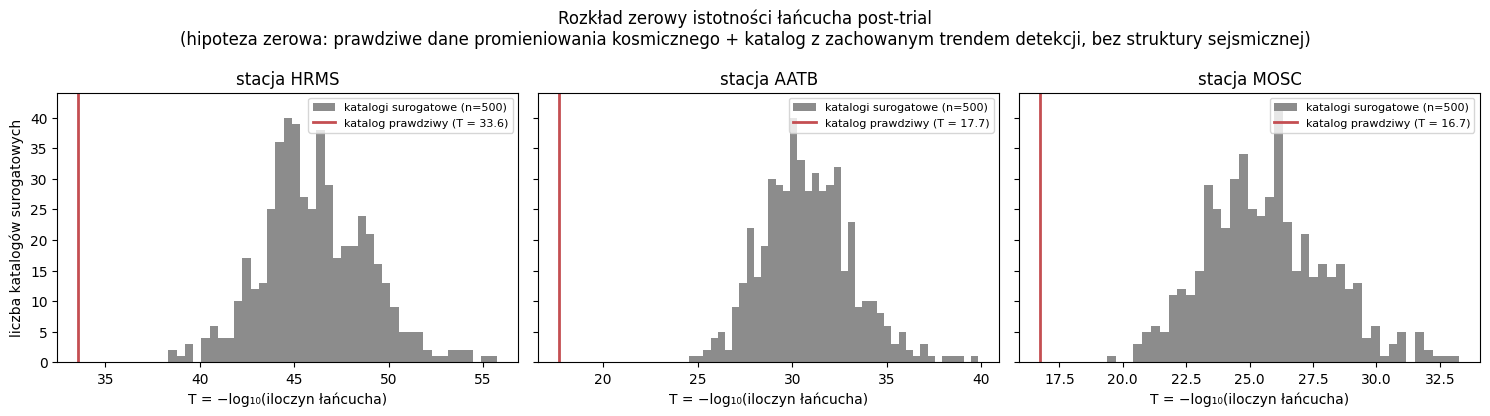

In [10]:
# Wykres 1 (jedno kodowanie: wysokosc slupka histogramu). Rozklad zerowy
# statystyki T z zaznaczona wartoscia prawdziwa, panel na stacje. Wariant
# a_z_wykluczeniem - ten, na ktorym opieraja sie liczby z 31.08.
import matplotlib.pyplot as plt

WARIANT_GLOWNY = "a_z_wykluczeniem"
fig, osie = plt.subplots(1, len(STACJE), figsize=(5 * len(STACJE), 4.2), sharey=True)
for ax, st in zip(np.atleast_1d(osie), STACJE):
    sur = surogaty_df[(surogaty_df.station == st)
                      & (surogaty_df.wariant == WARIANT_GLOWNY)]["T"].dropna()
    praw = float(prawdziwe[(prawdziwe.station == st)
                           & (prawdziwe.wariant == WARIANT_GLOWNY)]["T"].iloc[0])
    ax.hist(sur, bins=40, color="#8C8C8C", label=f"katalogi surogatowe (n={len(sur)})")
    ax.axvline(praw, color="#C44E52", lw=2,
               label=f"katalog prawdziwy (T = {praw:.1f})")
    ax.set_title(f"stacja {st.upper()}")
    ax.set_xlabel("T = −log₁₀(iloczyn łańcucha)")
    ax.legend(fontsize=8)
np.atleast_1d(osie)[0].set_ylabel("liczba katalogów surogatowych")
fig.suptitle("Rozkład zerowy istotności łańcucha post-trial\n"
             "(hipoteza zerowa: prawdziwe dane promieniowania kosmicznego + katalog "
             "z zachowanym trendem detekcji, bez struktury sejsmicznej)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/kalibracja_surogatowa_rozklad_T.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/kalibracja_surogatowa_rozklad_T.png")

Zapisano ../results/kalibracja_surogatowa_rozklad_minimum.png


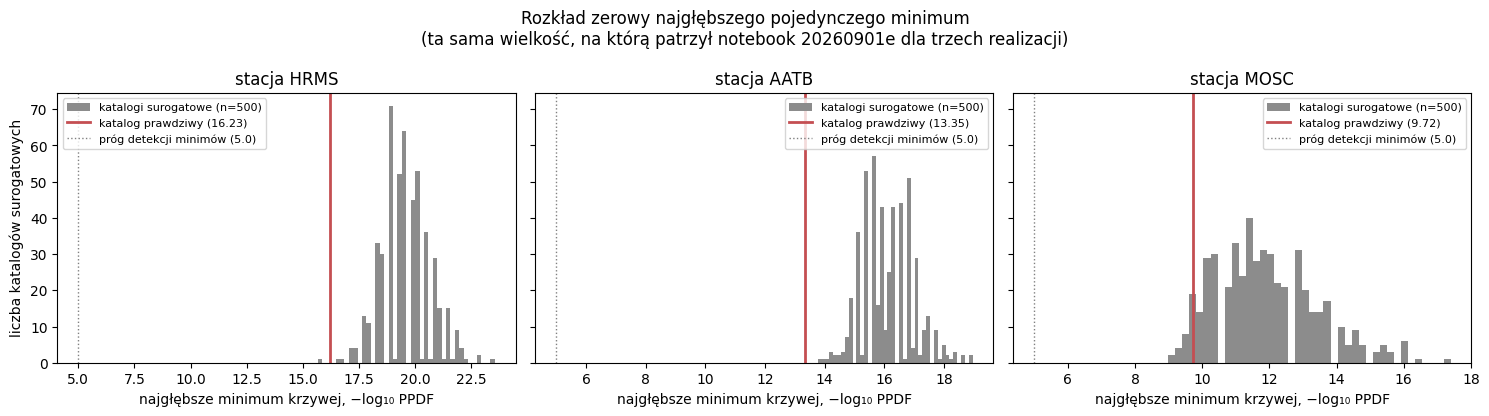

In [11]:
# Wykres 2 (jedno kodowanie: wysokosc slupka histogramu). To samo dla drugiej,
# prostszej statystyki: najglebsze pojedyncze minimum calej krzywej. Osobny
# wykres, a nie druga seria na poprzednim - te dwie statystyki maja inne skale
# i inne znaczenie, a wykres ma odpowiadac na jedno pytanie.
fig, osie = plt.subplots(1, len(STACJE), figsize=(5 * len(STACJE), 4.2), sharey=True)
for ax, st in zip(np.atleast_1d(osie), STACJE):
    sur = surogaty_df[(surogaty_df.station == st)
                      & (surogaty_df.wariant == WARIANT_GLOWNY)]["max_krzywej"].dropna()
    praw = float(prawdziwe[(prawdziwe.station == st)
                           & (prawdziwe.wariant == WARIANT_GLOWNY)]["max_krzywej"].iloc[0])
    ax.hist(sur, bins=40, color="#8C8C8C", label=f"katalogi surogatowe (n={len(sur)})")
    ax.axvline(praw, color="#C44E52", lw=2, label=f"katalog prawdziwy ({praw:.2f})")
    ax.axvline(PROG_WYSOKOSCI, color="gray", ls=":", lw=1,
               label=f"próg detekcji minimów ({PROG_WYSOKOSCI})")
    ax.set_title(f"stacja {st.upper()}")
    ax.set_xlabel("najgłębsze minimum krzywej, −log₁₀ PPDF")
    ax.legend(fontsize=8)
np.atleast_1d(osie)[0].set_ylabel("liczba katalogów surogatowych")
fig.suptitle("Rozkład zerowy najgłębszego pojedynczego minimum\n"
             "(ta sama wielkość, na którą patrzył notebook 20260901e dla trzech realizacji)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/kalibracja_surogatowa_rozklad_minimum.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/kalibracja_surogatowa_rozklad_minimum.png")

Zapisano ../results/kalibracja_surogatowa_liczba_minimow.png


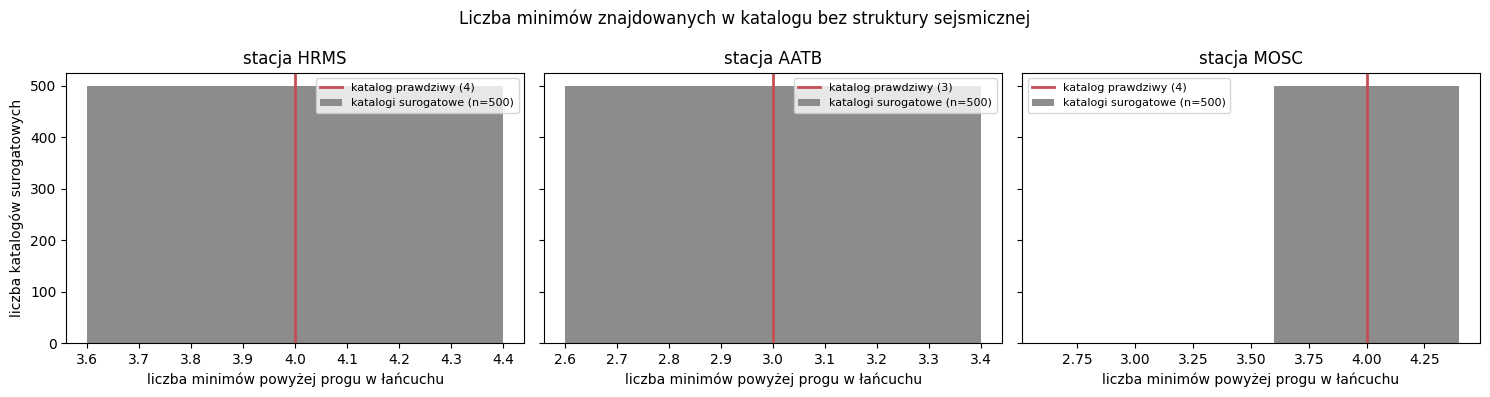

In [12]:
# Wykres 3 (jedno kodowanie: wysokosc slupka). Ile minimow powyzej progu
# znajduje find_peaks w katalogu surogatowym - rozklad, z wartoscia prawdziwa.
# To jest kontrola do zdania z 01.09, ze "surogaty odtwarzaja rytm": jesli
# typowy surogat ma tyle samo minimow co prawdziwy katalog, to sama LICZBA
# minimow nie niesie zadnej informacji o zwiazku CR-EQ.
fig, osie = plt.subplots(1, len(STACJE), figsize=(5 * len(STACJE), 4.0), sharey=True)
for ax, st in zip(np.atleast_1d(osie), STACJE):
    sur = surogaty_df[(surogaty_df.station == st)
                      & (surogaty_df.wariant == WARIANT_GLOWNY)]["n_minimow"]
    praw = int(prawdziwe[(prawdziwe.station == st)
                         & (prawdziwe.wariant == WARIANT_GLOWNY)]["n_minimow"].iloc[0])
    zliczenia = sur.value_counts().sort_index()
    ax.bar(zliczenia.index, zliczenia.values, color="#8C8C8C",
           label=f"katalogi surogatowe (n={len(sur)})")
    ax.axvline(praw, color="#C44E52", lw=2, label=f"katalog prawdziwy ({praw})")
    ax.set_title(f"stacja {st.upper()}")
    ax.set_xlabel("liczba minimów powyżej progu w łańcuchu")
    ax.legend(fontsize=8)
np.atleast_1d(osie)[0].set_ylabel("liczba katalogów surogatowych")
fig.suptitle("Liczba minimów znajdowanych w katalogu bez struktury sejsmicznej")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/kalibracja_surogatowa_liczba_minimow.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/kalibracja_surogatowa_liczba_minimow.png")

In [13]:
# PODSUMOWANIE, czytane wedlug regul ustalonych w komorce 0 PRZED liczeniem.
print("=" * 78)
print("EMPIRYCZNA KALIBRACJA ISTOTNOSCI - PODSUMOWANIE")
print("=" * 78)
print()
print("Reguly odczytu, ustalone przed zobaczeniem wyniku (dla statystyki T,")
print("wariant a_z_wykluczeniem):")
print("  p_emp < 0,01  -> efekt przezywa kalibracje")
print("  0,01 - 0,2    -> istotnosc realna, ale o rzedy wielkosci mniejsza")
print("  p_emp >= 0,2  -> lancuch nie odroznia sie od katalogu bez sejsmiki")
print()

g = kalibracja[(kalibracja.wariant == WARIANT_GLOWNY)
               & (kalibracja.statystyka == "T (lancuch)")]
for r in g.itertuples():
    if r.p_emp < 0.01:
        odczyt = "efekt PRZEZYWA kalibracje"
    elif r.p_emp < 0.2:
        odczyt = "istotnosc realna, ale duzo mniejsza niz raportowana"
    else:
        odczyt = "BRAK odroznienia od katalogu bez sejsmiki"
    if r.p_na_podlodze:
        opis_p = (f"p_emp <= {r.p_emp:.4f} (zaden surogat nie dorownal prawdziwemu; "
                  f"to PODLOGA rozdzielczosci przy N = {r.n_surogatow})")
    elif r.p_na_suficie:
        opis_p = (f"p_emp = {r.p_emp:.4f} - prawdziwy katalog jest SLABSZY niz "
                  f"praktycznie kazdy surogat")
    else:
        opis_p = f"p_emp = {r.p_emp:.4f}"
    print(f"{r.station.upper():5s}  T = {r.wartosc_prawdziwa:6.2f}   "
          f"mediana surogatow {r.surogat_mediana:6.2f}, "
          f"95. centyl {r.surogat_p95:6.2f}, maksimum {r.surogat_max:6.2f}")
    print(f"       {opis_p}")
    print(f"       {r.sigma_emp:.2f} sigma empirycznie (sigma przycieta do zakresu "
          f"rozstrzyganego przez N); z normalny {r.z_normalny:.2f}  ->  {odczyt}")
print()
print("Zestawienie z liczbami raportowanymi wczesniej dla tych samych lancuchow")
print("(metoda wolna, wariant a; z results/section4_penalized_chain_per_era.csv):")
for st in STACJE:
    ref_T = ODNIESIENIE[(st, "a_z_wykluczeniem")]
    print(f"  {st:5s} sigma nominalna z lancucha = {norm.isf(10 ** -ref_T):.2f}")
print()
print("OGRANICZENIA - bez nich tego wyniku nie wolno cytowac:")
print(f"  - Podloga rozdzielczosci: przy {N_SUROGATOW} surogatach najmniejsze")
print(f"    mierzalne p to {1 / (1 + N_SUROGATOW):.4f}. Jesli p_emp na niej lezy,")
print("    wynik jest NIERownoscia, a nie liczba; kolumna z_normalny mowi tylko,")
print("    czy prawdziwa wartosc lezy tuz za podloga, czy o rzedy dalej.")
print("  - Surogat niszczy takze grupowanie wstrzasow wtornych, ktore jest realna")
print("    struktura sejsmiczna. Odrzucenie H0 nie dowodzi wiec zwiazku CR-EQ -")
print("    moglaby za nie odpowiadac autokorelacja katalogu.")
print("  - Kalibracja dotyczy metody WOLNEJ. Metody stalego punktu (na ktorej")
print("    stoja liczby 7,40 / 6,45 z 31.08) skalibrowac sie w ten sposob nie da,")
print("    bo jej daty pochodza z prawdziwych danych - patrz komorka 0.")
print("  - Trzy stacje to nie trzy niezalezne wyniki: k_eff calej sieci to ~2")
print("    (20260901a.ipynb), a hrms i aatb sa w tej sieci najsilniejsze.")

EMPIRYCZNA KALIBRACJA ISTOTNOSCI - PODSUMOWANIE

Reguly odczytu, ustalone przed zobaczeniem wyniku (dla statystyki T,
wariant a_z_wykluczeniem):
  p_emp < 0,01  -> efekt przezywa kalibracje
  0,01 - 0,2    -> istotnosc realna, ale o rzedy wielkosci mniejsza
  p_emp >= 0,2  -> lancuch nie odroznia sie od katalogu bez sejsmiki

HRMS   T =  33.56   mediana surogatow  45.87, 95. centyl  50.57, maksimum  55.77
       p_emp = 1.0000 - prawdziwy katalog jest SLABSZY niz praktycznie kazdy surogat
       -2.88 sigma empirycznie (sigma przycieta do zakresu rozstrzyganego przez N); z normalny -4.50  ->  BRAK odroznienia od katalogu bez sejsmiki
AATB   T =  17.67   mediana surogatow  30.64, 95. centyl  34.85, maksimum  39.84
       p_emp = 1.0000 - prawdziwy katalog jest SLABSZY niz praktycznie kazdy surogat
       -2.88 sigma empirycznie (sigma przycieta do zakresu rozstrzyganego przez N); z normalny -5.53  ->  BRAK odroznienia od katalogu bez sejsmiki
MOSC   T =  16.74   mediana surogatow  25.47